In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.figure_factory as ff
import plotly.offline as pyo
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_auc_score, classification_report
import itertools


In [54]:
df = pd.read_csv('creditcard.csv')
# Display dataset structure
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [55]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [56]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [57]:
print(df.isnull().sum())


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Class
0    284315
1       492
Name: count, dtype: int64


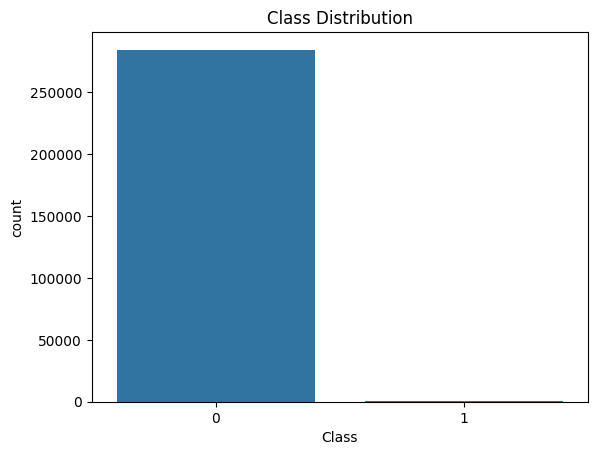

In [58]:
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()


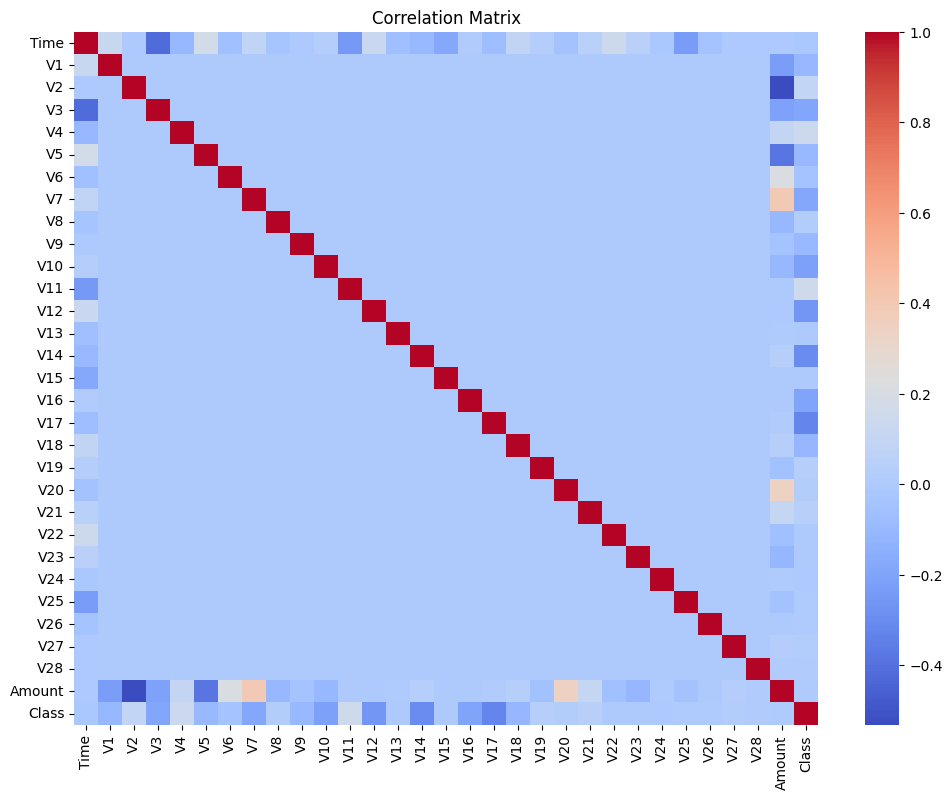

In [59]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [60]:
pip install plotly


In [61]:
import plotly.io as pio
pio.renderers.default = 'colab'


In [62]:
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)


In [65]:
# Fix for Plotly in Google Colab (no need for offline init)
import plotly.figure_factory as ff
import plotly.io as pio
pio.renderers.default = 'colab'  # <- Set Colab as default renderer

# Prepare data
fraud_times = df[df['Class'] == 1]['Time']
nonfraud_times = df[df['Class'] == 0]['Time']

hist_data = [nonfraud_times, fraud_times]
group_labels = ['Not Fraud', 'Fraud']

# Create plot
fig = ff.create_distplot(
    hist_data,
    group_labels,
    show_hist=False,
    show_rug=False
)

fig.update_layout(
    title='⏱️ Credit Card Transactions Time Density Plot',
    xaxis_title='Time (seconds)',
    yaxis_title='Density',
    template='plotly_white'
)

#show plot
fig.show()


In [14]:
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600))

tmp = df.groupby(['Hour', 'Class'])['Amount'].aggregate(['min', 'max', 'count', 'sum', 'mean', 'median', 'var']).reset_index()
df_agg = pd.DataFrame(tmp)
df_agg.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']

df_agg.head()


,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0.0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0.0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1.0,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1.0,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2.0,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437


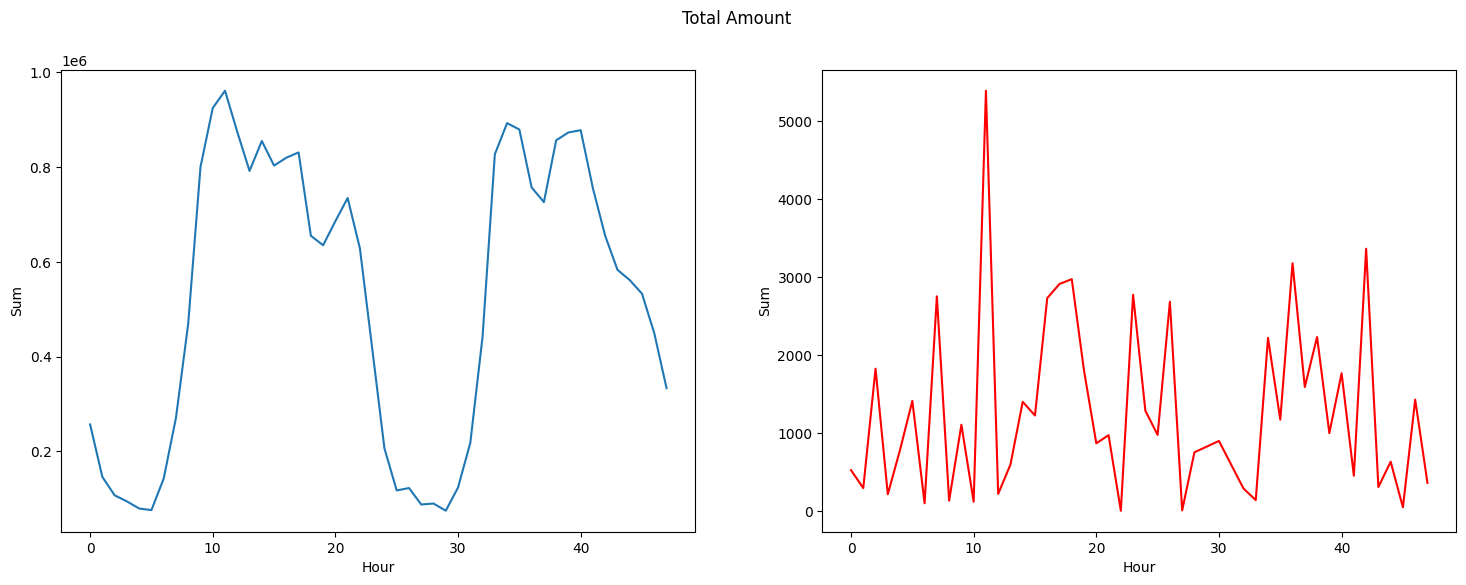

In [15]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
sns.lineplot(ax=ax1, x="Hour", y="Sum", data=df_agg[df_agg.Class==0])
sns.lineplot(ax=ax2, x="Hour", y="Sum", data=df_agg[df_agg.Class==1], color="red")
plt.suptitle("Total Amount")
plt.show()


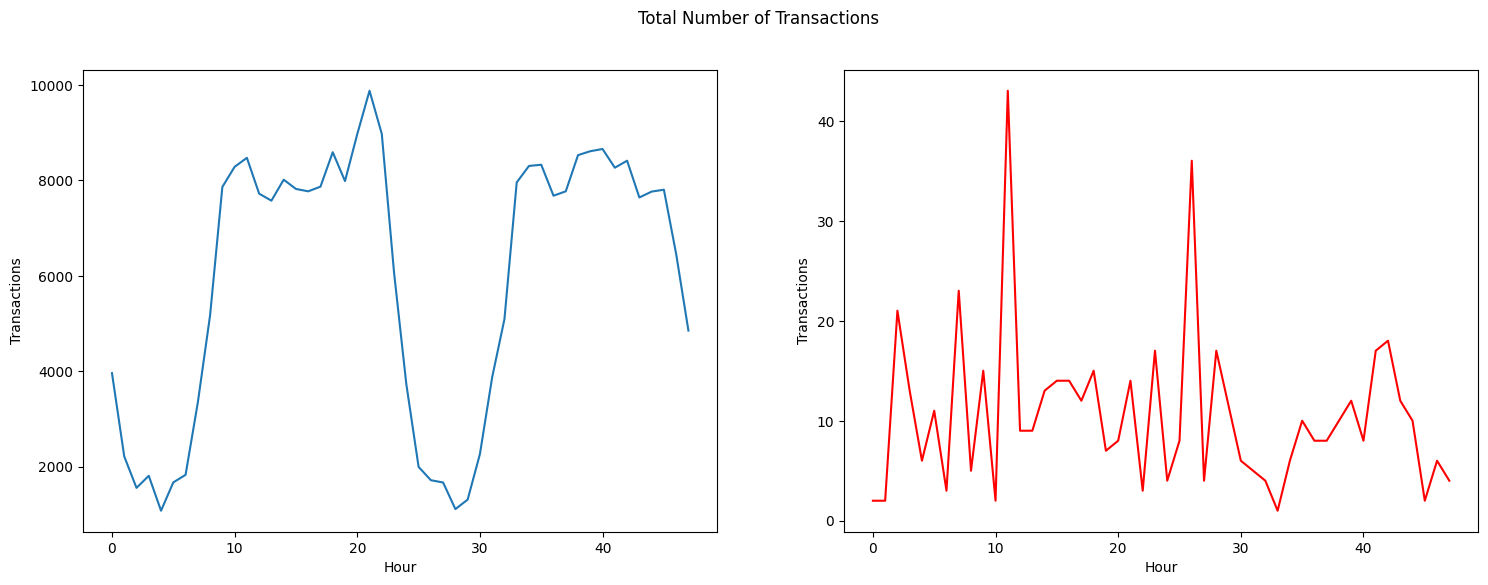

In [16]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
sns.lineplot(ax=ax1, x="Hour", y="Transactions", data=df_agg[df_agg.Class==0])
sns.lineplot(ax=ax2, x="Hour", y="Transactions", data=df_agg[df_agg.Class==1], color="red")
plt.suptitle("Total Number of Transactions")
plt.show()


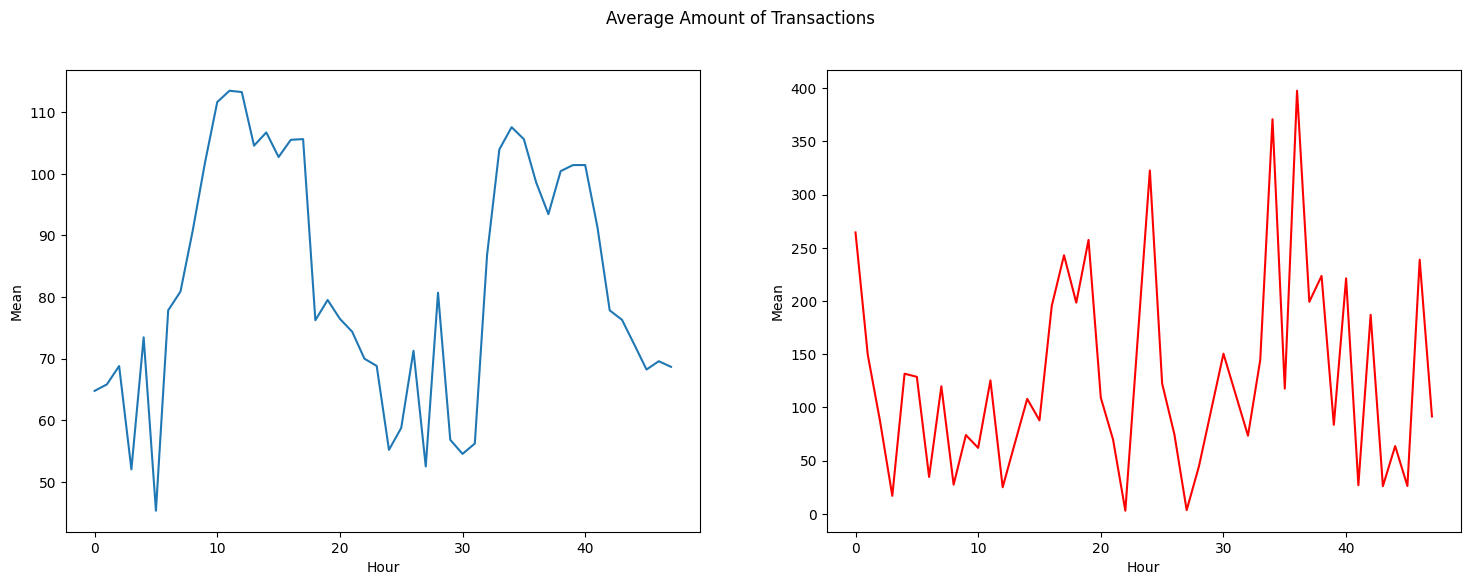

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))

sns.lineplot(ax=ax1, x="Hour", y="Mean", data=df_agg[df_agg.Class==0])
sns.lineplot(ax=ax2, x="Hour", y="Mean", data=df_agg[df_agg.Class==1], color="red")

plt.suptitle("Average Amount of Transactions")
plt.show()


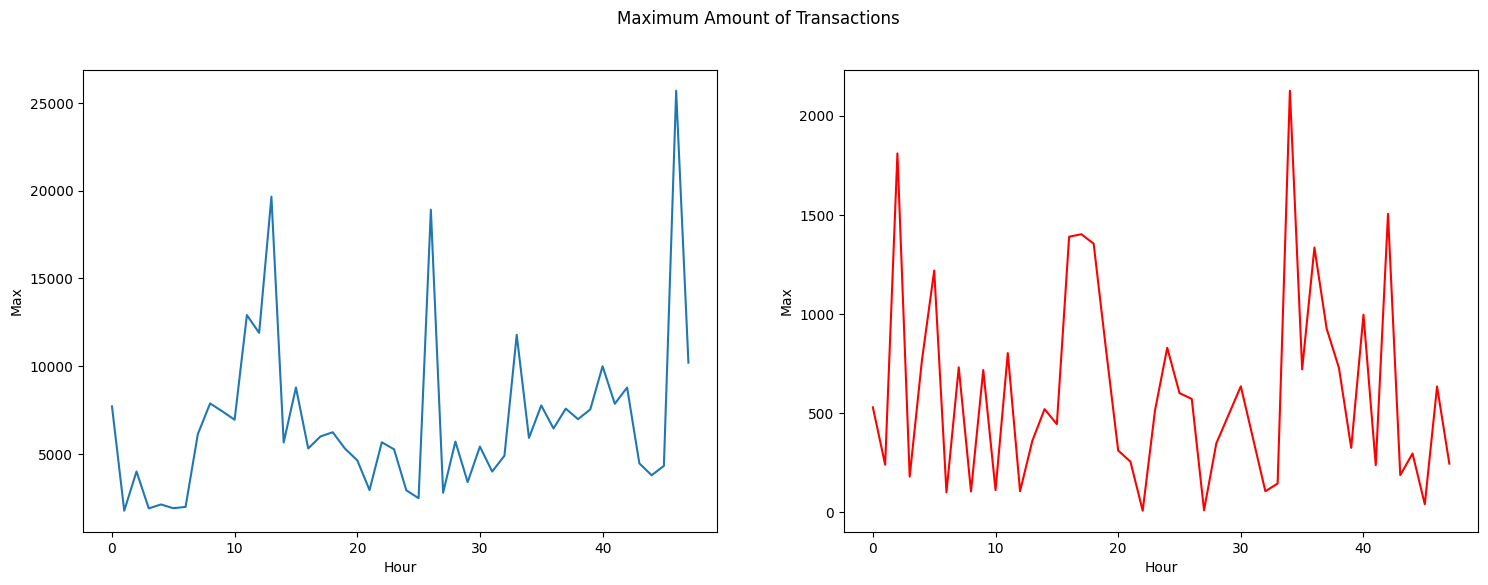

In [18]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
sns.lineplot(ax = ax1, x="Hour", y="Max", data=df_agg[df_agg.Class==0])
sns.lineplot(ax = ax2, x="Hour", y="Max", data=df_agg[df_agg.Class==1], color="red")
plt.suptitle("Maximum Amount of Transactions")
plt.show();

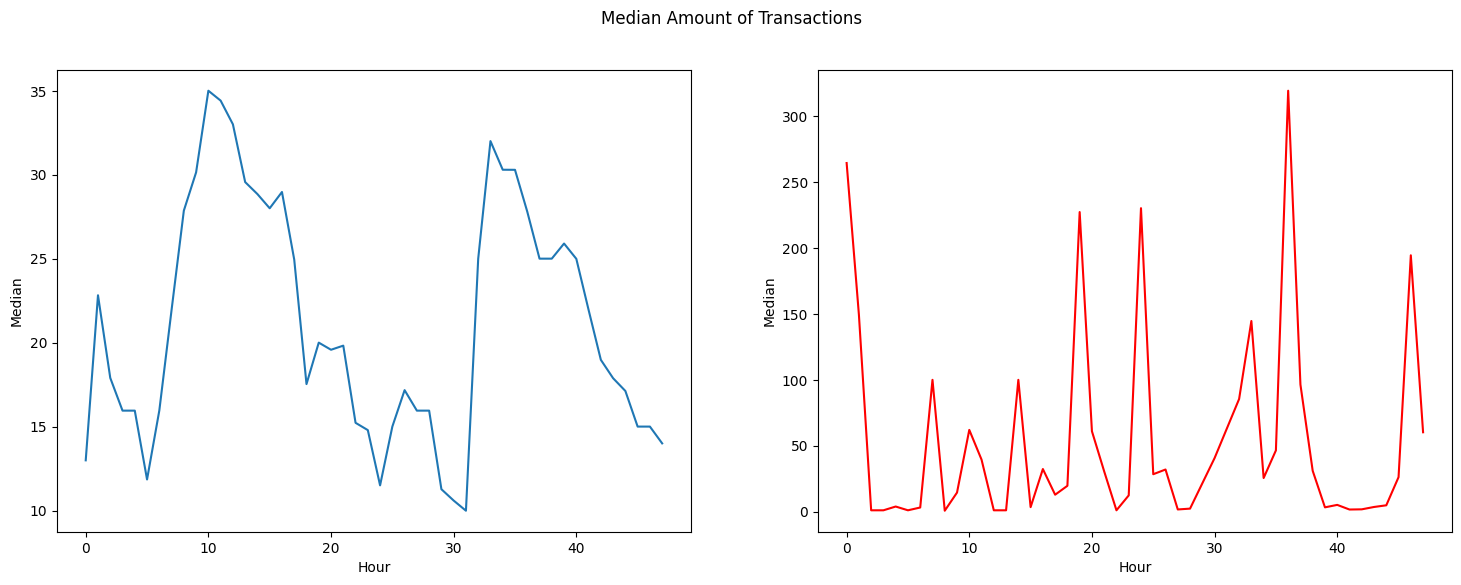

In [19]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
sns.lineplot(ax = ax1, x="Hour", y="Median", data=df_agg[df_agg.Class==0])
sns.lineplot(ax = ax2, x="Hour", y="Median", data=df_agg[df_agg.Class==1], color="red")
plt.suptitle("Median Amount of Transactions")
plt.show();

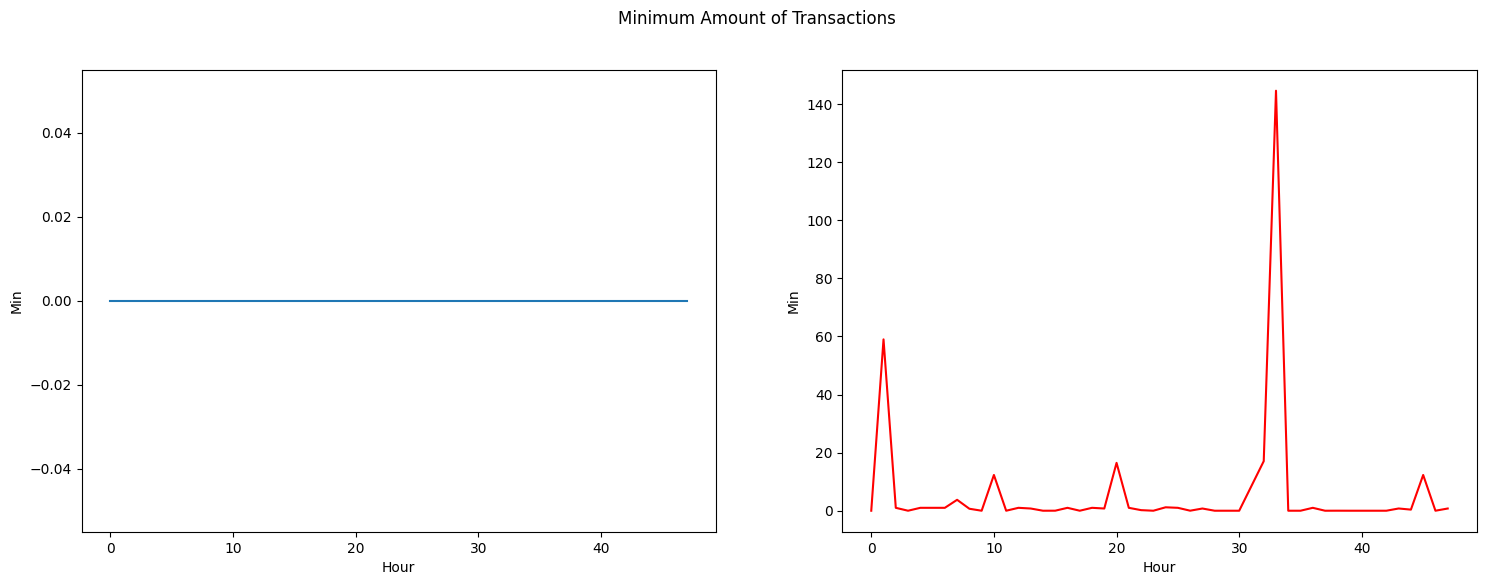

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,6))
sns.lineplot(ax = ax1, x="Hour", y="Min", data=df_agg[df_agg.Class==0])
sns.lineplot(ax = ax2, x="Hour", y="Min", data=df_agg[df_agg.Class==1], color="red")
plt.suptitle("Minimum Amount of Transactions")
plt.show();

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['scaled_time', 'scaled_amount']] = scaler.fit_transform(df[['Time', 'Amount']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)


In [70]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


Random Forest ROC-AUC Score: 0.9768


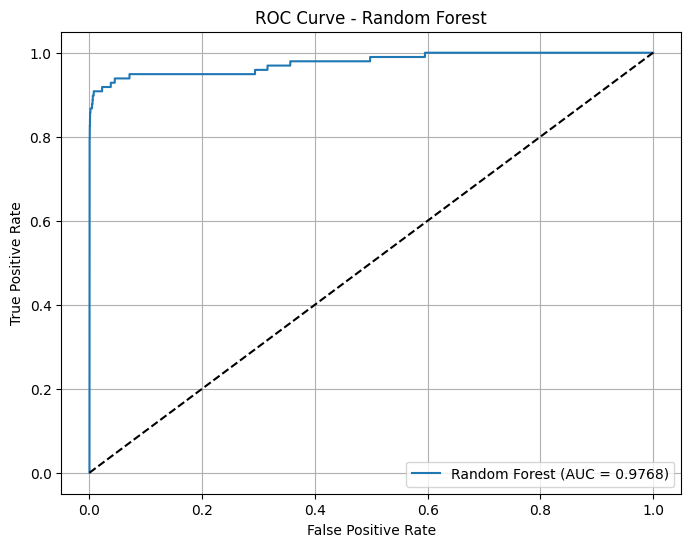

In [81]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities for ROC curve
y_proba_rf = rf.predict_proba(X_test)[:, 1]  # Probabilities for class 1 (fraud)

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, y_proba_rf)
print("Random Forest ROC-AUC Score:", round(roc_auc, 4))

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='Random Forest (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()

Logistic Regression ROC-AUC Score: 0.9698


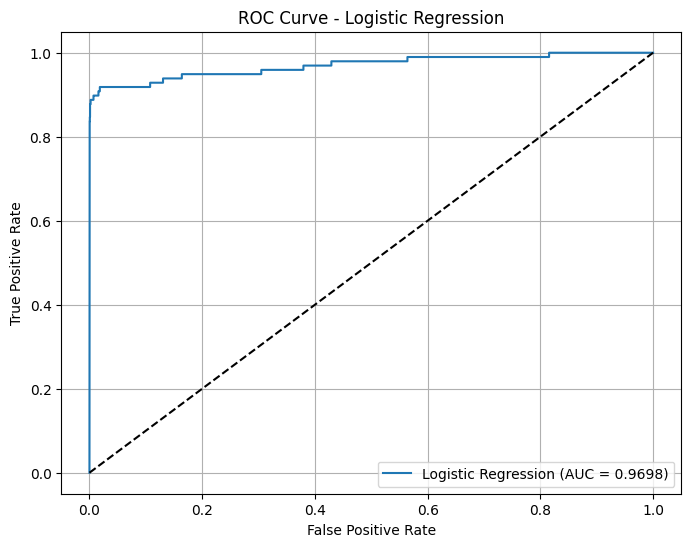

In [97]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities for ROC curve
y_proba_lr = lr.predict_proba(X_test)[:, 1]  # Probabilities for class 1 (fraud)

# Calculate ROC AUC
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
print("Logistic Regression ROC-AUC Score:", round(roc_auc_lr, 4))

# Plot ROC Curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = %0.4f)' % roc_auc_lr)
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [82]:
y_pred = lr.predict(X_test)  # for Logistic Regression
# or
y_pred = rf.predict(X_test)  # for Random Forest

In [83]:
y_pred = lr.predict(X_test)

In [84]:
y_pred = rf.predict(X_test)

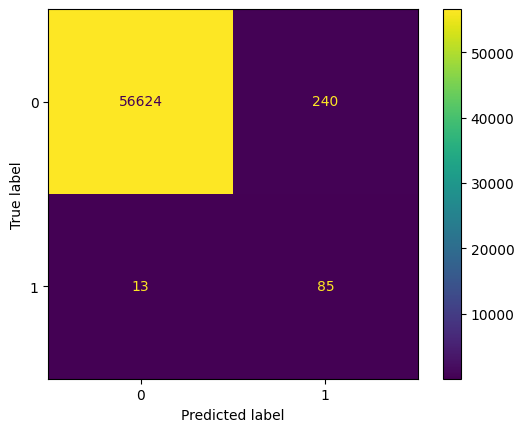

In [86]:
y_pred = rf.predict(X_test)  # or lr.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression AUC:", roc_auc_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression AUC: 0.9463636115673055
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ✅ Initialize Random Forest (no max_iter)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# ✅ Train on balanced data (SMOTE applied)
rf.fit(X_train_sm, y_train_sm)

# ✅ Predict on original unbalanced test data
y_pred_rf = rf.predict(X_test)

# ✅ Evaluation
print("Random Forest AUC:", roc_auc_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest AUC: 0.9182618320260012
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

